# Extracting features from gestures and sign

## Setting

In [2]:
import os
import glob
import pandas as pd
import numpy as np
from scipy.signal import find_peaks
import antropy as ent

curfolder = os.getcwd()
datasetsfolder = curfolder + '/Datasets'
processedfolder = curfolder + '/TS_processed'
#annos = pd.read_csv(curfolder + '/GtST_DGS_allSigns.txt', sep='\t')

mtfiles = glob.glob(processedfolder + '/*body_world.csv')
#handfiles = glob.glob(processedfolder + '/*hands_world.csv')


In [3]:
# how many files do we have?
print('Number of files:', len(mtfiles))

Number of files: 12867


# Taking care of problematic files

In [4]:
# load in problems_visibility_all.txt
problems_visibility = pd.read_csv(curfolder + '/problems_visibility_all.txt', sep='\t', header=None)
problems_visibility


,0
0,LP01_02_KOFFER_body_world
1,flipped_IP10_02_LAPTOP_body_world
2,LP17_02_SCHAL_body_world
3,IP08_02_BRILLE_body_world
4,LP18_02_TELEFONANRUF_body_world
...,...
2077,LP18_01_LIPPENSTIFT AUFTRAGEN_body_world
2078,IP08_02_SCHLANGE_body_world
2079,GP10_KISSEN_body_world
2080,LP06_01_PILOT_body_world


In [5]:
# create col ID and take first element of the string _
# if flipped in 0, take first two, otherwise take first one
if problems_visibility[0].str.contains('flipped_').any():
    problems_visibility['ID'] = problems_visibility[0].apply(lambda x: x.split('_')[0] + '_' + x.split('_')[1])
else:
    problems_visibility['ID'] = problems_visibility[0].apply(lambda x: x.split('_')[0])

In [6]:
# how many unique IDs do we have?
print('Number of unique IDs in problems_visibility:', len(problems_visibility['ID'].unique()))

# how many times is each ID in problems_visibility?
print('Number of times each ID appears in problems_visibility:')
print(problems_visibility['ID'].value_counts())

# add .csv to the first column
problems_visibility[0] = problems_visibility[0].apply(lambda x: x + '.csv')

Number of unique IDs in problems_visibility: 90
Number of times each ID appears in problems_visibility:
ID
LP38_01         133
flipped_IP08    126
LP01_01         120
IP08_02         118
LP14_01         104
               ... 
GP02_FISCH        1
GP16_GRAS         1
GP14_PISTOLE      1
GP17_GRAUSAM      1
GP10_KISSEN       1
Name: count, Length: 90, dtype: int64


For now, we will get rid of them to ensure the best quality MT

In [7]:
# get rid of files from mtfiles that match first column of problems_visibility

mtfiles_clean = [f for f in mtfiles if os.path.basename(f) not in problems_visibility[0].values]


In [7]:
# how many is in mtfiles_clean?
print('Number of files in mtfiles_clean:', len(mtfiles_clean))

Number of files in mtfiles_clean: 10785


# Checking z-dimension

In [10]:
zcoord = {}

# Loop over the files and extract firs z-coordinate of R-shoulder
for mtfile in mtfiles_clean:
    #print(mtfile)
    if 'video_raw' in mtfile:
        id = os.path.basename(mtfile).split('_')[4]  # Extract ID from filename
    elif 'flipped' in mtfile:
        id = os.path.basename(mtfile).split('_')[1]
    else:
        id = os.path.basename(mtfile).split('_')[0]  # Extract ID from filename
    #print('ID:', id)

    # load in the data
    df = pd.read_csv(mtfile)

    # get the first z-coordinate of RShoulder_z
    if 'Z_RIGHT_SHOULDER' in df.columns:
        if id in zcoord:
            #append it
            zcoord[id].append(df['Z_RIGHT_SHOULDER'].iloc[0])
        else:
            # create a new entry
            zcoord[id] = [df['Z_RIGHT_SHOULDER'].iloc[0]]

            


In [12]:
zcoord_mean = {}

# Loop over the zcoord dictionary and calculate the mean
for id, zvalues in zcoord.items():
    zcoord_mean[id] = np.mean(zvalues)

# Create a DataFrame from the zcoord_mean dictionary
zcoord_mean_df = pd.DataFrame.from_dict(zcoord_mean, orient='index', columns=['Z_RIGHT_SHOULDER_MEAN'])

In [15]:
zcoord_mean_df

,Z_RIGHT_SHOULDER_MEAN
LP28,-0.156993
LP29,-0.154055
LP06,-0.135272
LP30,-0.109346
LP33,-0.160959
LP07,-0.093384
LP04,-0.083137
LP01,-0.157581
LP08,-0.076580
LP13,-0.120581


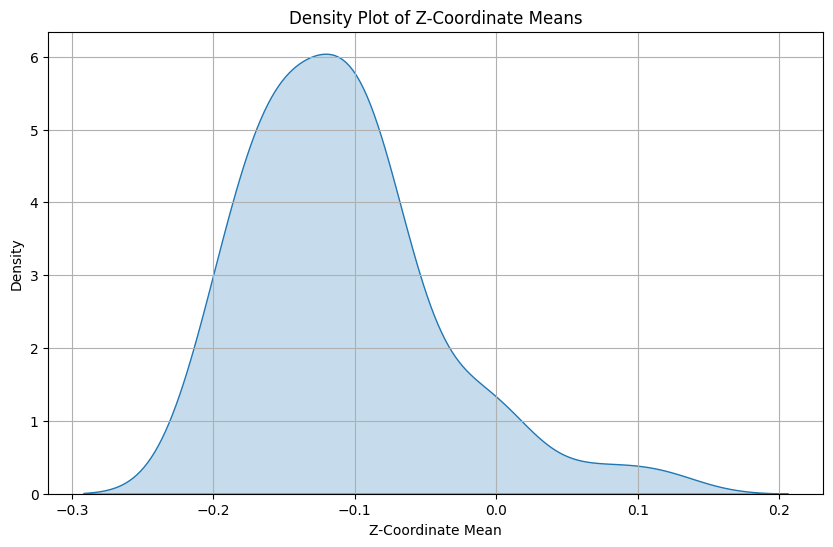

In [14]:
# density plot
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.kdeplot(zcoord_mean_df['Z_RIGHT_SHOULDER_MEAN'], fill=True)
plt.title('Density Plot of Z-Coordinate Means')
plt.xlabel('Z-Coordinate Mean')
plt.ylabel('Density')
plt.grid()
plt.show()

# Functions needed

In [8]:
## function to calculate bbmv
def get_bbmv(df, keypoint):
    # get spans in each dimension
    x_span = df['X_' + keypoint].max() - df['X_' + keypoint].min()
    y_span = df['Y_' + keypoint].max() - df['Y_' + keypoint].min()
    z_span = df['Z_' + keypoint].max() - df['Z_' + keypoint].min()

    # calculate bbmv
    bbmv = x_span * y_span * z_span

    return bbmv

## function for intermittency (adapted from Wim's paper)
def get_intermittency(jerk_values, speed_values):
    """Calculate the dimensionless smoothness measure using precomputed smoothed jerk and speed."""
    smoothed_jerk = jerk_values
    speed = speed_values
    
    if not np.all(speed == 0):
        integrated_squared_jerk = np.sum(smoothed_jerk ** 2)
        max_squared_speed = np.max(speed ** 2)
        D3 = len(speed) ** 3
        jerk_dimensionless = integrated_squared_jerk * (D3 / max_squared_speed)
        smoothness = jerk_dimensionless
    else:
        smoothness = np.nan

    return smoothness


In [9]:

def compute_ArmCoupling(df, keypoints=['WRIST'], dimensions=['X', 'Y', 'Z'], absolute=True):
    correlations = []
    
    for kp in keypoints:
        for dim in dimensions:
            left_col = f"{dim}_LEFT_{kp}"
            right_col = f"{dim}_RIGHT_{kp}"
                
            if left_col in df.columns and right_col in df.columns:
                corr = np.corrcoef(df[left_col], df[right_col])[0, 1]  # Pearson correlation
                if absolute:
                    corr = np.abs(corr)
                correlations.append(corr)
    
    return np.nanmean(correlations)  # Average correlation across keypoints and dimensions

def compute_multimovementAssymetry(df):
    joints = ['elbow_flex', 'wrist_flex', 'arm_flex']
    
    integral_diff_left = 0
    integral_diff_right = 0
    joint_integral_differences = []

    for joint in joints:
        joint_r_speed = f"right_{joint}_speed"
        joint_l_speed = f"left_{joint}_speed"
            
        if joint_r_speed in df.columns and joint_l_speed in df.columns:
            # Compute the integral of velocity (sum of speed over time) for left and right joints
            integral_velocity_left = np.sum(np.abs(df[joint_l_speed]))  # Sum of absolute speed
            integral_velocity_right = np.sum(np.abs(df[joint_r_speed]))  # Sum of absolute speed

            # Compute the difference in integral of angular velocity between left and right 
            # the more +, the more distance is left is travelling), 
            joint_integral_diff = integral_velocity_left - integral_velocity_right
            joint_integral_differences.append(joint_integral_diff)

            # Accumulate for total integral difference calculation
            integral_diff_left += integral_velocity_left
            integral_diff_right += integral_velocity_right

    # Compute the overall difference in integrated velocities
    total_integral_difference = np.mean(joint_integral_differences)  # Mean of differences across joints

    return {
        'mean_integral_difference': total_integral_difference,
        'joint_integral_differences': joint_integral_differences,
        'total_left_integral_velocity': integral_diff_left,
        'total_right_integral_velocity': integral_diff_right
    }


# Normalizing ts by trunk length

We will first loop over all files and collect the length of the mid-shoulder - mid-hip vector per each trial, saving it to dictionary for each participant.

In [10]:
trunk_length = {}

def compute_trunk_length(df):
    # create mid-hip point
    df['X_MID_HIP'] = (df['X_LEFT_HIP'] + df['X_RIGHT_HIP']) / 2
    df['Y_MID_HIP'] = (df['Y_LEFT_HIP'] + df['Y_RIGHT_HIP']) / 2
    df['Z_MID_HIP'] = (df['Z_LEFT_HIP'] + df['Z_RIGHT_HIP']) / 2

    # create mid-shoulder point
    df['X_MID_SHOULDER'] = (df['X_LEFT_SHOULDER'] + df['X_RIGHT_SHOULDER']) / 2
    df['Y_MID_SHOULDER'] = (df['Y_LEFT_SHOULDER'] + df['Y_RIGHT_SHOULDER']) / 2
    df['Z_MID_SHOULDER'] = (df['Z_LEFT_SHOULDER'] + df['Z_RIGHT_SHOULDER']) / 2

    # calculate trunk length
    trunk_length = np.sqrt(
        (df['X_MID_SHOULDER'] - df['X_MID_HIP']) ** 2 +
        (df['Y_MID_SHOULDER'] - df['Y_MID_HIP']) ** 2 +
        (df['Z_MID_SHOULDER'] - df['Z_MID_HIP']) ** 2
    )

    return trunk_length.mean()  # Return the mean trunk length across the dataframe

for mtfile in mtfiles_clean:
    #print(mtfile)
    if 'video_raw' in mtfile:
        id = os.path.basename(mtfile).split('_')[4]  # Extract ID from filename
    elif 'flipped' in mtfile:
        id = os.path.basename(mtfile).split('_')[1]
    else:
        id = os.path.basename(mtfile).split('_')[0]  # Extract ID from filename
    #print('ID:', id)

    # load in the data
    df = pd.read_csv(mtfile)

    # compute trunk length
    trunklength = compute_trunk_length(df)
    # # store trunk length in dictionary, if the id already exists, add it there
    if id in trunk_length:
        trunk_length[id].append(trunklength)
    else:
        trunk_length[id] = [trunklength]

# now for each key, compute mean trunk length
mean_trunk_length = {}
for key in trunk_length.keys():
    mean_trunk_length[key] = np.mean(trunk_length[key])

    #break

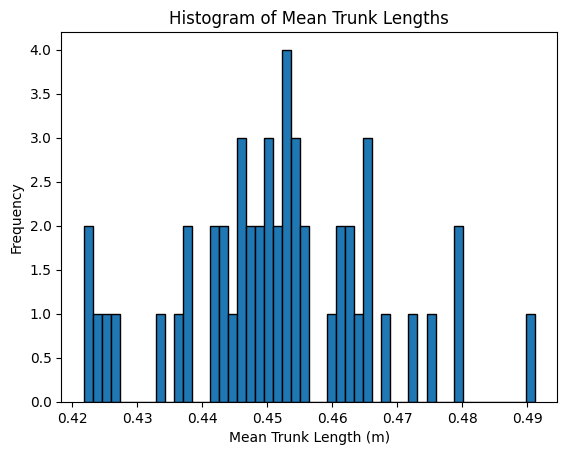

In [11]:
# histogram of trunk lengths
import matplotlib.pyplot as plt
plt.hist(list(mean_trunk_length.values()), bins=50, edgecolor='black')
plt.xlabel('Mean Trunk Length (m)')
plt.ylabel('Frequency')
plt.title('Histogram of Mean Trunk Lengths')
plt.show()

Now we want to write a function which takes a df and normalizes all by the length saved in the dictionary.

In [11]:
def normalize_by_trunkL(df, id, trunk_length_dict):
    """Normalize the coordinates by the mean trunk length."""
    # get the trunk length for the id
    if id in trunk_length_dict:
        trunk_length = trunk_length_dict[id]
    else:
        print(f"Trunk length for ID {id} not found.")
        return df
    
    # normalize all numerical columns
    numcols = df.select_dtypes(include=[np.number]).columns.tolist()
    for col in numcols:
        df[col] = df[col] / trunk_length
    return df

# Create distance columns (non-normalized)

In [17]:
for mtfile in mtfiles_clean:
    df = pd.read_csv(mtfile)

    # check if lwrist_nose col exists, if so, skip this file
    if 'lwrist_nose' in df.columns:
        print(f"Skipping {mtfile} as it already has location parameters.")
        continue


    # add location parameters - calculate distance wrist-nose, wrist-hips, wrist-shoulders
    lwrist_nose = np.sqrt((df['X_LEFT_WRIST'] - df['X_NOSE'])**2 + (df['Y_LEFT_WRIST'] - df['Y_NOSE'])**2 + (df['Z_LEFT_WRIST'] - df['Z_NOSE'])**2)
    lwrist_nose.name = 'lwrist_nose'
    rwrist_nose = np.sqrt((df['X_RIGHT_WRIST'] - df['X_NOSE'])**2 + (df['Y_RIGHT_WRIST'] - df['Y_NOSE'])**2 + (df['Z_RIGHT_WRIST'] - df['Z_NOSE'])**2)
    rwrist_nose.name = 'rwrist_nose'
    lwrist_rhip = np.sqrt((df['X_LEFT_WRIST'] - df['X_RIGHT_HIP'])**2 + (df['Y_LEFT_WRIST'] - df['Y_RIGHT_HIP'])**2 + (df['Z_LEFT_WRIST'] - df['Z_RIGHT_HIP'])**2)
    lwrist_rhip.name = 'lwrist_rhip'
    lwrist_lhip = np.sqrt((df['X_LEFT_WRIST'] - df['X_LEFT_HIP'])**2 + (df['Y_LEFT_WRIST'] - df['Y_LEFT_HIP'])**2 + (df['Z_LEFT_WRIST'] - df['Z_LEFT_HIP'])**2)
    lwrist_lhip.name = 'lwrist_lhip'
    rwrist_lhip = np.sqrt((df['X_RIGHT_WRIST'] - df['X_LEFT_HIP'])**2 + (df['Y_RIGHT_WRIST'] - df['Y_LEFT_HIP'])**2 + (df['Z_RIGHT_WRIST'] - df['Z_LEFT_HIP'])**2)
    rwrist_lhip.name = 'rwrist_lhip'
    rwrist_rhip = np.sqrt((df['X_RIGHT_WRIST'] - df['X_RIGHT_HIP'])**2 + (df['Y_RIGHT_WRIST'] - df['Y_RIGHT_HIP'])**2 + (df['Z_RIGHT_WRIST'] - df['Z_RIGHT_HIP'])**2)
    rwrist_rhip.name = 'rwrist_rhip'
    lwrist_lshoulder = np.sqrt((df['X_LEFT_WRIST'] - df['X_LEFT_SHOULDER'])**2 + (df['Y_LEFT_WRIST'] - df['Y_LEFT_SHOULDER'])**2 + (df['Z_LEFT_WRIST'] - df['Z_LEFT_SHOULDER'])**2)
    lwrist_lshoulder.name = 'lwrist_lshoulder'
    lwrist_rshoulder = np.sqrt((df['X_LEFT_WRIST'] - df['X_RIGHT_SHOULDER'])**2 + (df['Y_LEFT_WRIST'] - df['Y_RIGHT_SHOULDER'])**2 + (df['Z_LEFT_WRIST'] - df['Z_RIGHT_SHOULDER'])**2)
    lwrist_rshoulder.name = 'lwrist_rshoulder'
    rwrist_lshoulder = np.sqrt((df['X_RIGHT_WRIST'] - df['X_LEFT_SHOULDER'])**2 + (df['Y_RIGHT_WRIST'] - df['Y_LEFT_SHOULDER'])**2 + (df['Z_RIGHT_WRIST'] - df['Z_LEFT_SHOULDER'])**2)
    rwrist_lshoulder.name = 'rwrist_lshoulder'
    rwrist_rshoulder = np.sqrt((df['X_RIGHT_WRIST'] - df['X_RIGHT_SHOULDER'])**2 + (df['Y_RIGHT_WRIST'] - df['Y_RIGHT_SHOULDER'])**2 + (df['Z_RIGHT_WRIST'] - df['Z_RIGHT_SHOULDER'])**2)
    rwrist_rshoulder.name = 'rwrist_rshoulder'

    df = pd.concat([df, lwrist_nose, rwrist_nose, lwrist_rhip, lwrist_lhip, rwrist_lhip, rwrist_rhip, lwrist_lshoulder, lwrist_rshoulder, rwrist_lshoulder, rwrist_rshoulder], axis=1)

    # save it again
    pd.DataFrame(df).to_csv(mtfile, index=False)


Skipping e:\VICOM_SignGes_Trajectory/TS_processed\LP28_01_BASKETBALL_body_world.csv as it already has location parameters.


# Alternative: distance of wrists from torso plane/center

In [17]:
import numpy as np
import pandas as pd

def point_to_plane_distance(P, P0, n):
    return np.einsum('ij,ij->i', P - P0, n) / np.linalg.norm(n, axis=1)

def smooth_series(series, window=5):
    return pd.Series(series).rolling(window=window, min_periods=1, center=True).mean()

# Your sampling rate (Hz)
sampling_rate = 30.0
dt = 1.0 / sampling_rate

for mtfile in mtfiles_clean:
    df = pd.read_csv(mtfile)

    if 'lwrist_plane' in df.columns:
        print(f"Skipping {mtfile} – already contains torso metrics.")
        continue

    # Keypoints
    LSH = df[['X_LEFT_SHOULDER',  'Y_LEFT_SHOULDER',  'Z_LEFT_SHOULDER']].values
    RSH = df[['X_RIGHT_SHOULDER', 'Y_RIGHT_SHOULDER', 'Z_RIGHT_SHOULDER']].values
    LHIP= df[['X_LEFT_HIP',       'Y_LEFT_HIP',       'Z_LEFT_HIP']].values
    RHIP= df[['X_RIGHT_HIP',      'Y_RIGHT_HIP',      'Z_RIGHT_HIP']].values
    LW  = df[['X_LEFT_WRIST',     'Y_LEFT_WRIST',     'Z_LEFT_WRIST']].values
    RW  = df[['X_RIGHT_WRIST',    'Y_RIGHT_WRIST',    'Z_RIGHT_WRIST']].values

    # Torso plane normal
    n = np.cross(RSH - LSH, RHIP - LSH)

    # Torso centre
    centre = (LSH + RSH + LHIP + RHIP) / 4.0

    # Distances (unsigned)
    lwrist_plane = np.abs(point_to_plane_distance(LW, centre, n))
    rwrist_plane = np.abs(point_to_plane_distance(RW, centre, n))
    lwrist_centre = np.linalg.norm(LW - centre, axis=1)
    rwrist_centre = np.linalg.norm(RW - centre, axis=1)

    # Convert to smoothed series
    df['lwrist_plane'] = smooth_series(lwrist_plane)
    df['rwrist_plane'] = smooth_series(rwrist_plane)
    df['lwrist_centre'] = smooth_series(lwrist_centre)
    df['rwrist_centre'] = smooth_series(rwrist_centre)

    # Add smoothed torso centre coordinates (optional)
    df['torsoCentre_X'] = smooth_series(centre[:, 0])
    df['torsoCentre_Y'] = smooth_series(centre[:, 1])
    df['torsoCentre_Z'] = smooth_series(centre[:, 2])

    # First and second derivatives (speed and acceleration)
    for label in ['lwrist_plane', 'rwrist_plane', 'lwrist_centre', 'rwrist_centre']:
        dist = df[label]
        speed = dist.diff() / dt
        accel = speed.diff() / dt
        df[label + '_speed'] = smooth_series(speed)
        df[label + '_accel'] = smooth_series(accel)

    # Save
    df.to_csv(mtfile, index=False)
    #df
    #break


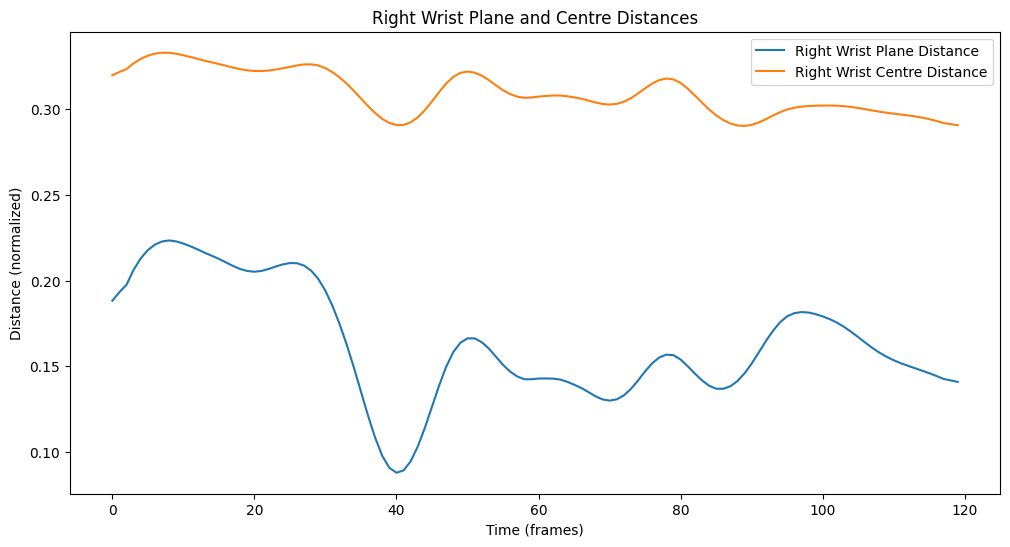

In [16]:
#plot rwrist_plane an rwrist_centre
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 6))
plt.plot(df['lwrist_plane'], label='Right Wrist Plane Distance')
plt.plot(df['lwrist_centre'], label='Right Wrist Centre Distance')
plt.title('Right Wrist Plane and Centre Distances')
plt.xlabel('Time (frames)')
plt.ylabel('Distance (normalized)')
plt.legend()
plt.show()


# Collecting global mean for each column
 
 (We need it for minimum height of peaks)

In [18]:
# create empty dictionary to store results
global_means = {}
global_sds = {}

for mtfile in mtfiles_clean:
    #print(mtfile)
    if 'video_raw' in mtfile:
        id = os.path.basename(mtfile).split('_')[4]  # Extract ID from filename
    elif 'flipped' in mtfile:
        id = os.path.basename(mtfile).split('_')[1]
    else:
        id = os.path.basename(mtfile).split('_')[0]  # Extract ID from filename
    #print('ID:', id)

    # load in the data
    df = pd.read_csv(mtfile)

    # normalize the data by trunk length
    df_normalized = normalize_by_trunkL(df, id, mean_trunk_length)

    # get global mean for each column
    colstocol = df_normalized.columns.tolist()
    # get rid of nonumerical columns
    colstocol = [col for col in colstocol if df_normalized[col].dtype in [np.float64, np.int64]]
    # and time
    colstocol = [col for col in colstocol if col != 'time']
    
    # collect means
    for col in colstocol:
        mean = df_normalized[col].mean()
        sd = df_normalized[col].std()
        # if col not in global_means, create it
        if col not in global_means:
            global_means[col] = []
            global_means[col].append(mean)

        else:
            global_means[col].append(mean)

        if col not in global_sds:
            global_sds[col] = []
            global_sds[col].append(sd)
        else:
            global_sds[col].append(sd)





In [19]:
# now for each key, compute mean of means
global_means_final = {}
for key in global_means.keys():
    global_means_final[key] = np.mean(global_means[key])

# and for standard deviations
global_sds_final = {}
for key in global_sds.keys():
    global_sds_final[key] = np.mean(global_sds[key])


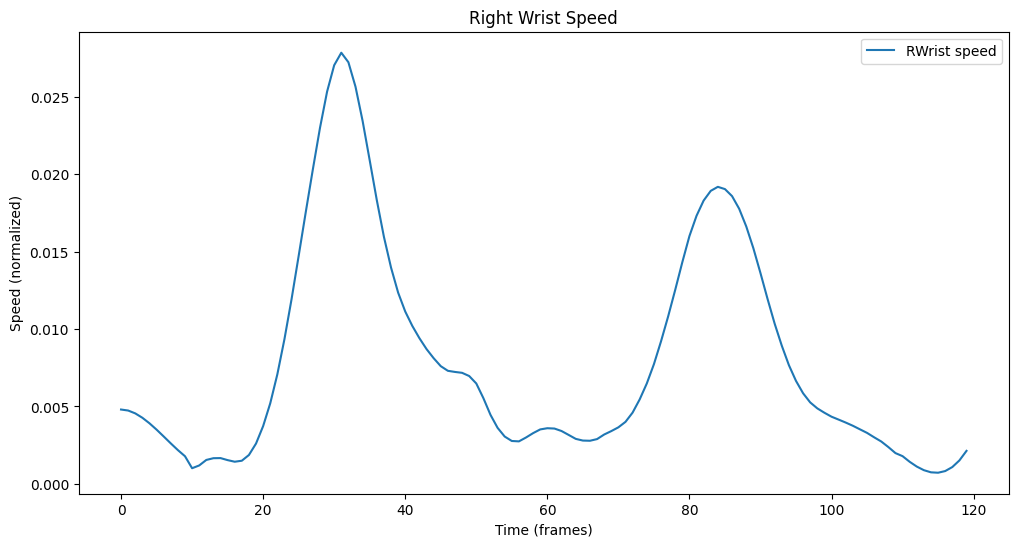

In [20]:
# plot speed of one mtfile
import matplotlib.pyplot as plt

mtfile = mtfiles_clean[0]
df = pd.read_csv(mtfile)
plt.figure(figsize=(12, 6))
plt.plot(df['RIGHT_WRIST_speed'], label='RWrist speed')
plt.title('Right Wrist Speed')
plt.xlabel('Time (frames)')
plt.ylabel('Speed (normalized)')
plt.legend()
plt.show()


# Extract features - full loop for body

In [28]:
# surpress warnings
import warnings
warnings.filterwarnings("ignore")

features_all_df = pd.DataFrame()

for file in mtfiles_clean:
    print('working on file: ', file)

    # get id
    if 'video_raw' in file:
        id = file.split('\\')[-1].split('_')[4]
    elif 'flipped' in file:
        id = file.split('\\')[-1].split('_')[1]
    else:
        id = file.split('\\')[-1].split('_')[0]

    # load it in
    df = pd.read_csv(file)

    # get fileID
    if 'flipped_' in file:
        flipped = True
        # get rid of the flipped
        fileID = file.split('\\')[-1].split('flipped_')[1]
        fileID = fileID.split('.')[0]
    else:
        flipped = False
        fileID = file.split('\\')[-1].split('.')[0]

    # if the file id contains LIGHTNING; TO-HEAR or GOAL,skip them because there are practice trials
    if 'LIGHTNING' in fileID or 'TO-HEAR' in fileID or 'GOAL' in fileID:
        continue

    # normalize the coordinates by the mean trunk length
    df = normalize_by_trunkL(df, id, mean_trunk_length)

    # ARM KINEMATICS

       ## add basic statistics for total_arm_speed, total_arm_jerk, total_arm_acceleration
    armtotalcols = ['total_arm_speed', 'total_arm_acceleration']
    arms_summary = {}
    for col in armtotalcols:
        # general mean
        gmean = df[col].mean()
        # general std
        gstd = df[col].std()
        # find peaks, height as mean
        globalmean = global_means_final[col] 
        globalstsd = global_sds_final[col]
        height = globalmean - 2*globalstsd  # Use mean - 2*std as the height for peak detection
        peak, _ = find_peaks(df[col], height=height)
        # find the peak values
        peak_values = df.loc[peak, col]
        # find the peak times
        peak_times = df.loc[peak, 'time'].tolist()
        # get peak mean
        peak_mean = peak_values.mean()
        # get peak std
        peak_std = peak_values.std()
        # peak n
        peak_n = len(peak_values)
        # compute the time between peaks
        peak_times_diff = np.diff(peak_times)
        # get the average time between peaks - rhytmicity/periodicity
        ipi_avg = peak_times_diff.mean()                                    #### FLAGGED. CHECK IF THIS IS ACTUALLY RHYTHMICITY
        # sample entropy
        ts = df[col].values
        ts_std = np.std(ts)
        sampen = ent.sample_entropy(ts, order=2)       ## FIX
        #sampen=0
        # integral
        integral = np.trapz(ts)
        # range of the ts
        ts_range = ts.max() - ts.min()

        # save in a dictionary
        arms_summary[col] = [gmean, gstd, peak_mean, peak_std, peak_n, ipi_avg, sampen, integral, ts_range]

    # make a row from the dictionary
    arms_summary_row = pd.DataFrame({key: [value] for key, value in arms_summary.items()})
    # for each column, create new column that will have the old name + _Gmean, _Gstd, _peak_mean, _peak_std, _peak_n
    for col in arms_summary_row.columns:
        arms_summary_row[col + '_Gmean'] = arms_summary_row[col].apply(lambda x: x[0])
        arms_summary_row[col + '_Gstd'] = arms_summary_row[col].apply(lambda x: x[1])
        arms_summary_row[col + '_peak_mean'] = arms_summary_row[col].apply(lambda x: x[2])
        arms_summary_row[col + '_peak_std'] = arms_summary_row[col].apply(lambda x: x[3])
        arms_summary_row[col + '_peak_n'] = arms_summary_row[col].apply(lambda x: x[4])
        arms_summary_row[col + '_ipi_avg'] = arms_summary_row[col].apply(lambda x: x[5])
        arms_summary_row[col + '_sampen'] = arms_summary_row[col].apply(lambda x: x[6])
        arms_summary_row[col + '_integral'] = arms_summary_row[col].apply(lambda x: x[7])
        arms_summary_row[col + '_ts_range'] = arms_summary_row[col].apply(lambda x: x[8])

    # get rid of all cols that don't have Gmean, etc.
    arms_summary_row = arms_summary_row[[col for col in arms_summary_row.columns if 'Gmean' in col or 'Gstd' in col or 'peak_mean' in col or 'peak_std' in col or 'peak_n' in col or 'ipi_avg' in col or 'sampen' in col or 'integral' in col or 'ts_range' in col]]

    # get rid of 'acceleration_integral' (=speed)
    arms_summary_row = arms_summary_row[[col for col in arms_summary_row.columns if 'acceleration_integral' not in col]] 

    # EXTRA FEATURES 

    ### bbmv for WRIST, ELBOW, SHOULDER
    bbmv_lwrist = get_bbmv(df, 'LEFT_WRIST')
    bbmv_rwrist = get_bbmv(df, 'RIGHT_WRIST')   
    bbmv_lelbow = get_bbmv(df, 'LEFT_ELBOW')            ### BBMV SHOULD BE PROBABLY ALSO LOGGED
    bbmv_relbow = get_bbmv(df, 'RIGHT_ELBOW')
    bbmv_lshoulder = get_bbmv(df, 'LEFT_SHOULDER')
    bbmv_rshoulder = get_bbmv(df, 'RIGHT_SHOULDER')
    bbmv_arms = bbmv_lwrist + bbmv_rwrist + bbmv_lelbow + bbmv_relbow + bbmv_lshoulder + bbmv_rshoulder
  
    # intermittency for whole arm
    jerk_arm_total = df['total_arm_jerk']
    speed_arm_total = df['total_arm_speed']
    intermittency_arm_total = get_intermittency(jerk_arm_total, speed_arm_total)

    # calculate arm coupling
    arm_coupling = compute_ArmCoupling(df, keypoints=['WRIST', 'ELBOW'], dimensions=['X', 'Y', 'Z'], absolute=True)
    # calculate multimovement assymetry
    multimovement_assymetry = compute_multimovementAssymetry(df)

    # create empty features_summary_row
    features_summary_row = pd.DataFrame()

    features_summary_row['intermittency_arm_total'] = intermittency_arm_total
    features_summary_row['bbmv_arms'] = bbmv_arms

    # append arm coupling
    features_summary_row['arm_coupling'] = arm_coupling
    features_summary_row['arm_asymmetry'] = multimovement_assymetry['mean_integral_difference']

    ## HOLDS

    
  
    ## DISTANCES
    distances = ['lwrist_centre', 'rwrist_centre']
    # to each, add _speed and _accel in the name and put the new names in the list
    distances_speed = [col + '_speed' for col in distances]
    #distances_accel = [col + '_accel' for col in distances] 
    #distances = distances + distances_speed + distances_accel

    # get all the basic statistics for these distances
    distances_summary = {}
    for col in distances:
        # general mean
        gmean = df[col].mean()
        # general std
        gstd = df[col].std()
        # find peaks, height as mean
        globalmean = global_means_final[col] 
        globalstsd = global_sds_final[col]
        height = globalmean - 2*globalstsd  # Use mean - 2*std as the height for peak detection
        peak, _ = find_peaks(df[col], height=height)
        # find the peak values
        peak_values = df.loc[peak, col]
        # get peak mean
        peak_mean = peak_values.mean()
        # get peak std
        peak_std = peak_values.std()
        # peak n
        peak_n = len(peak_values)
        # compute the time between peaks
        if len(peak) > 1:
            peak_times_diff = np.diff(peak)
            # get the average time between peaks - rhytmicity/periodicity
            ipi_avg = peak_times_diff.mean()                                    #### FLAGGED. CHECK IF THIS IS ACTUALLY RHYTHMICITY
        else:
            ipi_avg = np.nan
        # sample entropy
        ts_std = np.std(df[col].values)
        ts = df[col].values
        sampen = ent.sample_entropy(ts, order=2)       ## FIX
        #sampen=0
        # integral
        integral = np.trapz(ts)
        # range of the ts
        ts_range = ts.max() - ts.min()

        # save in a dictionary
        distances_summary[col] = [gmean, gstd, peak_mean, peak_std, peak_n, ipi_avg, sampen, integral, ts_range]

    # make a row from the dictionary
    distances_summary_row = pd.DataFrame({key: [value] for key, value in distances_summary.items()})
    # for each column, create new column that will have the old name + _Gmean, _Gstd, _peak_mean, _peak_std, _peak_n
    for col in distances_summary_row.columns:
        distances_summary_row[col + '_Gmean'] = distances_summary_row[col].apply(lambda x: x[0])
        distances_summary_row[col + '_Gstd'] = distances_summary_row[col].apply(lambda x: x[1])
        distances_summary_row[col + '_peak_mean'] = distances_summary_row[col].apply(lambda x: x[2])
        distances_summary_row[col + '_peak_std'] = distances_summary_row[col].apply(lambda x: x[3])
        distances_summary_row[col + '_peak_n'] = distances_summary_row[col].apply(lambda x: x[4])
        distances_summary_row[col + '_ipi_avg'] = distances_summary_row[col].apply(lambda x: x[5])
        distances_summary_row[col + '_sampen'] = distances_summary_row[col].apply(lambda x: x[6])
        distances_summary_row[col + '_integral'] = distances_summary_row[col].apply(lambda x: x[7])
        distances_summary_row[col + '_ts_range'] = distances_summary_row[col].apply(lambda x: x[8])

    # get rid of all cols that don't have Gmean, etc.
    distances_summary_row = distances_summary_row[[col for col in distances_summary_row.columns if 'Gmean' in col or 'Gstd' in col or 'peak_mean' in col or 'peak_std' in col or 'peak_n' in col or 'ipi_avg' in col or 'sampen' in col or 'integral' in col or 'ts_range' in col]]

    # get rid of 'accel_integral', 'plane_integral' or 'centre_integral
    distances_summary_row = distances_summary_row[[col for col in distances_summary_row.columns if 'accel_integral' not in col and 'plane_integral' not in col and 'centre_integral' not in col]]
    
    # META

    #  make an empty concept_row that we will fill with some values
    concept_row = pd.DataFrame({'fileID': None, 'concept': None, 'group': None}, index=[0])

    concept_row['fileID'] = fileID

    # create column group
    if flipped == True:
        concept_row['group'] = 'test_IP'
    else:
        if 'GtST' in fileID or 'GP' in fileID:
            concept_row['group'] = fileID.split('_')[0]
        elif 'LP' in fileID or 'IP' in fileID:
            concept_row['group'] = fileID.split('_')[0] + '_' + fileID.split('_')[1]
        elif 'ViCom' in fileID:
            concept_row['group'] = 'GtST_w'
        elif 'video_raw' in fileID:
            concept_row['group'] = 'FLESH'
        else:
            print('ERROR: fileID not in GtST, GP, LP, IP')
            break

    # column concept
    if 'GtST' in fileID:
        concept_row['concept'] = fileID.split('_')[2]
    elif 'GP' in fileID:
        concept_row['concept'] = fileID.split('_')[1]
    elif 'LP' in fileID or 'IP' in fileID:
        concept_row['concept'] = fileID.split('_')[2]
    elif 'ViCom' in fileID:
        concept_row['concept'] = fileID.split('_')[3]
    elif 'video_raw' in fileID:
        concept_row['concept'] = fileID.split('_')[5]

    # we need to correct few concepts
    if concept_row['concept'].values[0] == 'TO-PICK':
        concept_row['concept'] = 'TO-PLUCK'
    elif concept_row['concept'].values[0] == 'TO-MOVE-HOUSES':
        concept_row['concept'] = 'TO-MOVE'
    elif concept_row['concept'].values[0] == 'VIDEO-GAME':
        concept_row['concept'] = 'VIDEOGAME'


    ## ICONICITY
    # get the iconicity rating for this concept
    # try:
    #     iconicity_rating = iconicity[iconicity['item_EN'] == final_row['concept'].values[0]]['Iconicity'].values[0]
    # except IndexError:
    #     # indexeror
    #     iconicity_rating = np.nan
    ## add to final_row
    #final_row['iconicity'] = iconicity_rating

    ## ANNOTATIONS
    # get the annotation of handedness for this concept
    # try:	
    #     handedness = annos[annos['Sign/gesture'] == concept_row['concept'].values[0]]['Handedness'].values[0]
    # except IndexError:
    #     # indexeror
    #     handedness = np.nan
        
    # add to final_row
    #concept_row['handedness'] = handedness

    # concat all rows to features_all_df
    features_all = pd.concat([concept_row, arms_summary_row, distances_summary_row], axis=1)
    features_all_df = pd.concat([features_all_df, features_all])

# save them all 
features_all_df.to_csv(datasetsfolder + '/features_all_df.csv', index=False)

working on file:  e:\GtST_FLESH_KinTrajectory/TS_processed\LP28_01_BASKETBALL_body_world.csv
working on file:  e:\GtST_FLESH_KinTrajectory/TS_processed\LP28_01_BEINE_body_world.csv
working on file:  e:\GtST_FLESH_KinTrajectory/TS_processed\LP28_01_BEOBACHTEN_body_world.csv
working on file:  e:\GtST_FLESH_KinTrajectory/TS_processed\LP28_01_BEZAHLEN_body_world.csv
working on file:  e:\GtST_FLESH_KinTrajectory/TS_processed\LP28_01_BIER_body_world.csv
working on file:  e:\GtST_FLESH_KinTrajectory/TS_processed\LP28_01_BILLIARD_body_world.csv
working on file:  e:\GtST_FLESH_KinTrajectory/TS_processed\LP28_01_BODEN_body_world.csv
working on file:  e:\GtST_FLESH_KinTrajectory/TS_processed\LP28_01_BRECHEN_body_world.csv
working on file:  e:\GtST_FLESH_KinTrajectory/TS_processed\LP28_01_BRIEF_body_world.csv
working on file:  e:\GtST_FLESH_KinTrajectory/TS_processed\LP28_01_BRILLE_body_world.csv
working on file:  e:\GtST_FLESH_KinTrajectory/TS_processed\LP28_01_BUCH_body_world.csv
working on file

In [29]:
# show me unique groups + counts
print('Unique groups in features_all_df:')
groups = features_all_df['group'].value_counts()
groups


Unique groups in features_all_df:


group
GP06         363
GP18         363
GP15         363
GP01         362
GP03         362
            ... 
IP08_02       19
LP01_01       17
LP38_01        4
ViCom_128      1
ViCom_164      1
Name: count, Length: 71, dtype: int64

## Aftermath

In [30]:
#dfs = [features_all_df, features_kin_df, features_dist_df, features_hand_df]
dfs = [features_all_df]


def classify_group(x):
    if 'IP' in x and '_02' in x:
        return 'Learners_2'
    elif 'IP' in x and '_01' in x:
        return 'Learners_1'
    elif 'LP' in x and '_02' in x:
        return 'Learners_2'
    elif 'LP' in x and '_01' in x:
        return 'Learners_1'
    elif 'GtST' in x or 'ViCom' in x:
        return 'DGS'
    elif 'GP' in x:
        return 'Gesture'
    elif 'test' in x:
        return 'test'
    else:
        return x

# for each df, replace the group names
for df in dfs:
    df['group'] = df['group'].apply(lambda x: 'ViCom' if 'ViCom_' in x else x)
    df['group'] = df['group'].apply(lambda x: 'ViCom' if 'GtST_' in x else x)
    df['groupID'] = df['group'].apply(classify_group)
    # filter out rows where group=test or groupID=test
    df = df[df['group'] != 'test']
    df = df[df['groupID'] != 'test']

# save them datasetsfolder
features_all_df.to_csv(datasetsfolder + '/features_all_df_final.csv', index=False)


In [27]:
features_all_df

,fileID,concept,handedness,group,total_arm_speed_Gmean,total_arm_speed_Gstd,total_arm_speed_peak_mean,total_arm_speed_peak_std,total_arm_speed_peak_n,total_arm_speed_ipi_avg,...,rwrist_centre_accel_ts_range,rwrist_plane_accel_Gmean,rwrist_plane_accel_Gstd,rwrist_plane_accel_peak_mean,rwrist_plane_accel_peak_std,rwrist_plane_accel_peak_n,rwrist_plane_accel_ipi_avg,rwrist_plane_accel_sampen,rwrist_plane_accel_ts_range,groupID
0,LP28_01_BASKETBALL_body_world,BASKETBALL,None,LP28_01,8.144439,1.709339,10.245833,2.607167,8,1068.413990,...,9.053358,-0.040154,1.893734,2.071922,1.309164,8,16.285714,0.511912,9.101454,Learners_1
0,LP28_01_BEINE_body_world,BEINE,None,LP28_01,8.067151,6.820943,8.813803,2.166295,7,1221.553329,...,8.071894,0.013143,1.429166,0.759973,1.146894,10,12.444444,0.342791,8.924326,Learners_1
0,LP28_01_BEOBACHTEN_body_world,BEOBACHTEN,None,LP28_01,7.865703,2.831166,11.006083,4.203810,7,1221.553329,...,5.864694,0.006102,0.704040,0.586223,0.564959,11,10.200000,0.808979,3.440580,Learners_1
0,LP28_01_BEZAHLEN_body_world,BEZAHLEN,None,LP28_01,8.624344,5.589396,18.824534,18.659518,6,1226.539261,...,6.982326,-0.002923,1.077885,0.912773,0.850618,9,14.625000,0.537445,4.931778,Learners_1
0,LP28_01_BIER_body_world,BIER,None,LP28_01,10.112701,12.029262,9.777586,4.801404,10,855.918319,...,9.789476,0.039656,1.398572,1.100358,1.380471,11,11.100000,0.538997,7.248443,Learners_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,GP16_SCHNEIDEN_(Messer)_body_world,SCHNEIDEN,None,GP16,8.358220,2.412778,10.364327,2.827665,14,643.198028,...,8.713281,-0.018563,2.392819,2.273413,1.737285,14,15.846154,0.531493,11.417924,Gesture
0,GP16_SCHNEIDEN_(Schere)_body_world,SCHNEIDEN,None,GP16,7.415528,1.891542,8.220824,2.144817,16,597.874229,...,6.343848,-0.049028,1.402898,0.944918,1.703759,20,11.684211,0.511394,9.789712,Gesture
0,GP17_MORGEN_(nicht_heute)_body_world,MORGEN,None,GP17,8.339651,2.891990,10.475481,3.387375,14,649.697357,...,11.597527,0.039676,1.266560,1.148185,1.310677,15,14.714286,0.297184,7.745026,Gesture
0,GP17_MORGEN_(Tageszeit)_body_world,MORGEN,None,GP17,9.170465,10.267012,19.281361,34.009176,13,727.431165,...,6.864363,0.041465,1.434092,1.188272,1.387577,17,13.375000,0.276727,7.927245,Gesture


In [24]:
# within each col groupID, how many different values of col group there is?
group_counts = features_all_df.groupby('groupID')['group'].nunique().reset_index()
group_counts.columns = ['groupID', 'unique_groups_count']
group_counts


,groupID,unique_groups_count
0,DGS,2
1,FLESH,1
2,Gesture,14
3,Learners_1,31
4,Learners_2,20
5,test,1


In [26]:
# unique values of groupID
print('Unique values of groupID in df:')
print(features_all_df['groupID'].unique())


Unique values of groupID in df:
['Learners_1' 'Learners_2' 'FLESH' 'DGS' 'Gesture' 'test']


In [303]:
# show me rows where groupID is test
print('Rows where groupID is test:')
print(features_all_df[features_all_df['groupID'] == 'test'])

Rows where groupID is test:
                            fileID      concept handedness    group  \
0       IP06_02_ABHOLEN_body_world      ABHOLEN        NaN  test_IP   
0      IP06_02_ABLEHNEN_body_world     ABLEHNEN        NaN  test_IP   
0          IP06_02_AFFE_body_world         AFFE        NaN  test_IP   
0     IP06_02_AKKORDEON_body_world    AKKORDEON        NaN  test_IP   
0           IP06_02_ARM_body_world          ARM          1  test_IP   
..                             ...          ...        ...      ...   
0   IP10_02_VERHEIRATET_body_world  VERHEIRATET        NaN  test_IP   
0    IP10_02_VIDEOSPIEL_body_world   VIDEOSPIEL        NaN  test_IP   
0         IP10_02_VOGEL_body_world        VOGEL        NaN  test_IP   
0      IP10_02_VORHANG _body_world     VORHANG         NaN  test_IP   
0   IP10_02_VORSCHLAGEN_body_world  VORSCHLAGEN        NaN  test_IP   

    LEFT_WRIST_speed_norm_Gmean  LEFT_WRIST_speed_norm_Gstd  \
0                      5.323142                    5.062

In [35]:
# show me percentage of nans per column
nan_percentage = features_all_df.isna().mean() * 100
print('Percentage of NaNs per column:')
nan_percentage[nan_percentage > 0].sort_values(ascending=False)


Percentage of NaNs per column:


handedness                                92.049355
left_elbow_flex_ipi_avg                    5.241674
left_elbow_flex_peak_std                   5.241674
left_wrist_flex_ipi_avg                    5.056128
left_wrist_flex_peak_std                   5.056128
                                            ...    
RIGHT_WRIST_acceleration_norm_ipi_avg      0.018555
LEFT_WRIST_speed_norm_peak_std             0.009277
RIGHT_ELBOW_acceleration_norm_ipi_avg      0.009277
LEFT_WRIST_speed_norm_ipi_avg              0.009277
RIGHT_ELBOW_acceleration_norm_peak_std     0.009277
Length: 67, dtype: float64

# UMAP

## UMAP FOR KIN FEATURES

In [ ]:
from math import floor

features_df = pd.read_csv(datasetsfolder + '/features_kin_df_final.csv')

# get rid of FLESH from df
features_df = features_df[features_df['groupID'] != 'FLESH']

# get rid of col handedness
features_df = features_df.drop(columns=['handedness'])

# get rid of rows with nan in any col
features_df = features_df.dropna()

sampled_df_list = []

# Loop through each groupID
for groupID_val in features_df['groupID'].unique():
    sub_df = features_df[features_df['groupID'] == groupID_val]
    unique_groups = sub_df['group'].unique()
    n_groups = len(unique_groups)

    # Calculate how many samples per group to reach total of 150
    per_group_n = floor(250 / n_groups)

    for group_val in unique_groups:
        group_df = sub_df[sub_df['group'] == group_val]

        # Ensure we don’t oversample
        n_to_sample = min(per_group_n, len(group_df))
        sampled = group_df.sample(n=n_to_sample, random_state=42)
        sampled_df_list.append(sampled)

# Combine all sampled chunks
sampled_df = pd.concat(sampled_df_list).reset_index(drop=True)
# )
    

In [ ]:
import umap
from sklearn.preprocessing import StandardScaler

feat_df = sampled_df.copy()

# replace nan values with 0
#feat_df.fillna(0, inplace=True) 

reducer = umap.UMAP()

# get only numeric columns
features_df_num = feat_df._get_numeric_data()

# # drop NAs
# features_df_num = features_df_num.dropna()

# z-score all columns
features_df_scaled = StandardScaler().fit_transform(features_df_num)

# fit umap
embedding = reducer.fit_transform(features_df_scaled)
embedding.shape

(884, 2)

In [ ]:
import plotly.express as px
import pandas as pd

# First, make a DataFrame that includes the embedding coordinates
plot_df = pd.DataFrame({
    'x': embedding[:, 0],
    'y': embedding[:, 1],
    'group': feat_df['group'],
    'groupID': feat_df['groupID'],
    'concept': feat_df['concept']
})

# Use Plotly Express for a scatter plot with hover
fig = px.scatter(
    plot_df,
    x='x',
    y='y',
    color='groupID',       # Color by groupID
    symbol='group',        # Optional: differentiate by shape if not too many categories
    hover_name='concept',  # Show the concept name when hovering
    hover_data=['group', 'groupID'],  # Show additional info on hover
    title='UMAP projection (interactive)',
    opacity=0.6
)

# Optional: fix aspect ratio like in matplotlib
fig.update_layout(
    autosize=False,
    width=900,
    height=800,
    title_font_size=24,
    yaxis=dict(scaleanchor="x", scaleratio=1)
)

fig.show()


## UMAP FOR ANGL FEATURES

In [ ]:
from math import floor

features_df = pd.read_csv(datasetsfolder + '/features_angl_df_final.csv')

# get rid of FLESH from df
features_df = features_df[features_df['groupID'] != 'FLESH']

# get rid of col handedness
features_df = features_df.drop(columns=['handedness'])

# get rid of rows with nan in any col
features_df = features_df.dropna()

sampled_df_list = []

# Loop through each groupID
for groupID_val in features_df['groupID'].unique():
    sub_df = features_df[features_df['groupID'] == groupID_val]
    unique_groups = sub_df['group'].unique()
    n_groups = len(unique_groups)

    # Calculate how many samples per group to reach total of 150
    per_group_n = floor(250 / n_groups)

    for group_val in unique_groups:
        group_df = sub_df[sub_df['group'] == group_val]

        # Ensure we don’t oversample
        n_to_sample = min(per_group_n, len(group_df))
        sampled = group_df.sample(n=n_to_sample, random_state=42)
        sampled_df_list.append(sampled)

# Combine all sampled chunks
sampled_df = pd.concat(sampled_df_list).reset_index(drop=True)
# )
    

In [ ]:
import umap
from sklearn.preprocessing import StandardScaler

feat_df = sampled_df.copy()

# replace nan values with 0
feat_df.fillna(0, inplace=True) 

reducer = umap.UMAP()

# get only numeric columns
features_df_num = feat_df._get_numeric_data()

# drop NAs
#features_df_num = features_df_num.dropna()

# z-score all columns
features_df_scaled = StandardScaler().fit_transform(features_df_num)

# fit umap
embedding = reducer.fit_transform(features_df_scaled)
embedding.shape

(749, 2)

In [ ]:
import plotly.express as px
import pandas as pd

# First, make a DataFrame that includes the embedding coordinates
plot_df = pd.DataFrame({
    'x': embedding[:, 0],
    'y': embedding[:, 1],
    'group': feat_df['group'],
    'groupID': feat_df['groupID'],
    'concept': feat_df['concept']
})

# Use Plotly Express for a scatter plot with hover
fig = px.scatter(
    plot_df,
    x='x',
    y='y',
    color='groupID',       # Color by groupID
    symbol='group',        # Optional: differentiate by shape if not too many categories
    hover_name='concept',  # Show the concept name when hovering
    hover_data=['group', 'groupID'],  # Show additional info on hover
    title='UMAP projection (interactive)',
    opacity=0.6
)

# Optional: fix aspect ratio like in matplotlib
fig.update_layout(
    autosize=False,
    width=900,
    height=800,
    title_font_size=24,
    yaxis=dict(scaleanchor="x", scaleratio=1)
)

fig.show()


Here is probably where our distinction ViCom vs DGS signer happpens. Why??

## UMAP FOR DIST FEATURES

In [ ]:
from math import floor

features_df = pd.read_csv(datasetsfolder + '/features_dist_df_final.csv')

# get rid of FLESH from df
features_df = features_df[features_df['groupID'] != 'FLESH']

# get rid of col handedness
features_df = features_df.drop(columns=['handedness'])

# get rid of rows with nan in any col
features_df = features_df.dropna()

sampled_df_list = []

# Loop through each groupID
for groupID_val in features_df['groupID'].unique():
    sub_df = features_df[features_df['groupID'] == groupID_val]
    unique_groups = sub_df['group'].unique()
    n_groups = len(unique_groups)

    # Calculate how many samples per group to reach total of 150
    per_group_n = floor(250 / n_groups)

    for group_val in unique_groups:
        group_df = sub_df[sub_df['group'] == group_val]

        # Ensure we don’t oversample
        n_to_sample = min(per_group_n, len(group_df))
        sampled = group_df.sample(n=n_to_sample, random_state=42)
        sampled_df_list.append(sampled)

# Combine all sampled chunks
sampled_df = pd.concat(sampled_df_list).reset_index(drop=True)
# )
    

In [ ]:
import umap
from sklearn.preprocessing import StandardScaler

feat_df = sampled_df.copy()

# replace nan values with 0
feat_df.fillna(0, inplace=True) 

reducer = umap.UMAP()

# get only numeric columns
features_df_num = feat_df._get_numeric_data()

# drop NAs
#features_df_num = features_df_num.dropna()

# z-score all columns
features_df_scaled = StandardScaler().fit_transform(features_df_num)

# fit umap
embedding = reducer.fit_transform(features_df_scaled)
embedding.shape

(787, 2)

In [ ]:
import plotly.express as px
import pandas as pd

# First, make a DataFrame that includes the embedding coordinates
plot_df = pd.DataFrame({
    'x': embedding[:, 0],
    'y': embedding[:, 1],
    'group': feat_df['group'],
    'groupID': feat_df['groupID'],
    'concept': feat_df['concept']
})

# Use Plotly Express for a scatter plot with hover
fig = px.scatter(
    plot_df,
    x='x',
    y='y',
    color='groupID',       # Color by groupID
    symbol='group',        # Optional: differentiate by shape if not too many categories
    hover_name='concept',  # Show the concept name when hovering
    hover_data=['group', 'groupID'],  # Show additional info on hover
    title='UMAP projection (interactive)',
    opacity=0.6
)

# Optional: fix aspect ratio like in matplotlib
fig.update_layout(
    autosize=False,
    width=900,
    height=800,
    title_font_size=24,
    yaxis=dict(scaleanchor="x", scaleratio=1)
)

fig.show()


## UMAP FOR ALL FEATURES

In [379]:
# load in the df if you need
features_df = pd.read_csv(datasetsfolder + '/features_all_df_final.csv')
features_df

,fileID,concept,handedness,group,RIGHT_INDEX_speed_Gmean,RIGHT_INDEX_speed_Gstd,RIGHT_INDEX_speed_peak_mean,RIGHT_INDEX_speed_peak_std,RIGHT_INDEX_speed_peak_n,RIGHT_INDEX_speed_ipi_avg,...,right_wrist_flex_Gmean,right_wrist_flex_Gstd,right_wrist_flex_peak_mean,right_wrist_flex_peak_std,right_wrist_flex_peak_n,right_wrist_flex_ipi_avg,right_wrist_flex_sampen,right_wrist_flex_integral,right_wrist_flex_ts_range,groupID
0,LP28_01_BASKETBALL_body_world,BASKETBALL,1,LP28_01,0.010269,0.009028,0.023490,0.011517,3,866.666667,...,120.364924,2.733442,123.278863,2.084460,3,750.000000,0.278761,14326.976005,8.255606,Learners_1
1,LP28_01_BEINE_body_world,BEINE,NaN,LP28_01,0.005703,0.005895,0.014482,0.008014,3,833.333333,...,118.839455,3.099886,123.051987,3.038416,2,1233.333333,0.237410,14143.226975,10.817720,Learners_1
2,LP28_01_BEOBACHTEN_body_world,BEOBACHTEN,NaN,LP28_01,0.010770,0.011876,0.036217,0.003289,2,1700.000000,...,133.169382,16.096814,155.354363,1.008519,2,700.000000,0.068779,15859.037862,40.338420,Learners_1
3,LP28_01_BEZAHLEN_body_world,BEZAHLEN,NaN,LP28_01,0.010417,0.010947,0.034914,0.002398,2,1866.666667,...,128.294358,11.019748,141.240399,6.977965,2,1000.000000,0.119314,15276.441186,31.541555,Learners_1
4,LP28_01_BIER_body_world,BIER,NaN,LP28_01,0.011722,0.012031,0.032263,0.010759,3,683.333333,...,123.696409,9.130901,138.829839,2.529595,2,500.000000,0.064327,14725.106932,24.834981,Learners_1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10774,GP16_SCHNEIDEN_(Messer)_body_world,SCHNEIDEN,NaN,GP16,0.013433,0.005765,0.019960,0.002081,9,390.000000,...,138.071587,8.263130,151.341378,6.275479,3,1130.000000,0.320298,30934.075867,33.933707,Gesture
10775,GP16_SCHNEIDEN_(Schere)_body_world,SCHNEIDEN,NaN,GP16,0.007602,0.008433,0.025583,0.014513,2,560.000000,...,141.441514,4.781011,145.152930,1.806776,4,953.333333,0.090300,31685.387132,17.682847,Gesture
10776,GP17_MORGEN_(nicht_heute)_body_world,MORGEN,NaN,GP17,0.008252,0.007826,0.017383,0.007245,8,291.428571,...,138.802110,9.745042,153.003093,0.467820,3,570.000000,0.049293,31100.053794,24.744187,Gesture
10777,GP17_MORGEN_(Tageszeit)_body_world,MORGEN,NaN,GP17,0.008320,0.007476,0.022672,0.004493,4,560.000000,...,134.882740,7.379354,150.634245,1.067404,2,1060.000000,0.068884,30220.761249,23.651715,Gesture


In [354]:
# show me percentage of nans for each column
nan_perc = features_df.isna().mean() * 100
nan_perc[nan_perc > 0].sort_values(ascending=False)

handedness                            92.049355
right_arm_flex_peak_std               18.387606
right_arm_flex_ipi_avg                18.387606
right_wrist_flex_peak_std             18.127841
right_wrist_flex_ipi_avg              18.127841
                                        ...    
total_arm_jerk_peak_mean               0.009277
RIGHT_ELBOW_acceleration_peak_mean     0.009277
RIGHT_INDEX_speed_peak_mean            0.009277
LEFT_WRIST_speed_peak_mean             0.009277
RIGHT_WRIST_speed_peak_mean            0.009277
Length: 109, dtype: float64

In [380]:
from math import floor

# get rid of FLESH from df
features_df = features_df[features_df['groupID'] != 'FLESH']
features_df = features_df[features_df['groupID'] != 'test']


# get rid of col handedness
features_df = features_df.drop(columns=['handedness', 'right_arm_flex_peak_std', 'right_arm_flex_ipi_avg', 'right_wrist_flex_peak_std', 'right_wrist_flex_ipi_avg', 'left_arm_flex_peak_std', 'left_arm_flex_ipi_avg' ])

# get rid of rows with nan in any col
#features_df = features_df.dropna()

# replace nan values with 0
features_df.fillna(0, inplace=True)

sampled_df_list = []

# Loop through each groupID
for groupID_val in features_df['groupID'].unique():
    sub_df = features_df[features_df['groupID'] == groupID_val]
    unique_groups = sub_df['group'].unique()
    n_groups = len(unique_groups)

    # Calculate how many samples per group to reach total of 150
    per_group_n = floor(300 / n_groups)

    for group_val in unique_groups:
        group_df = sub_df[sub_df['group'] == group_val]

        # Ensure we don’t oversample
        n_to_sample = min(per_group_n, len(group_df))
        sampled = group_df.sample(n=n_to_sample, random_state=42)
        sampled_df_list.append(sampled)

# Combine all sampled chunks
sampled_df = pd.concat(sampled_df_list).reset_index(drop=True)
# )
    

In [381]:
# how many times each groupID appears in the df
group_counts = sampled_df['groupID'].value_counts()
group_counts

groupID
Learners_2    300
Gesture       294
DGS           287
Learners_1    274
Name: count, dtype: int64

In [382]:
# create column group_macro
# if groupID is Gesture, than group_macro is Gesture, else Sign
sampled_df['group_macro'] = sampled_df['groupID'].apply(lambda x: 'Gesture' if 'Gesture' in x else 'Sign')

In [383]:
import umap
from sklearn.preprocessing import StandardScaler


feat_df = sampled_df.copy()

reducer = umap.UMAP()

# get only numeric columns
features_df_num = feat_df._get_numeric_data()

# drop NAs
#features_df_num = features_df_num.dropna()

# replace nan values with 0
#features_df_num.fillna(0, inplace=True)

# z-score all columns
features_df_scaled = StandardScaler().fit_transform(features_df_num)

# fit umap
embedding = reducer.fit_transform(features_df_scaled)
embedding.shape

(1155, 2)

## UMAP - gesture vs sign

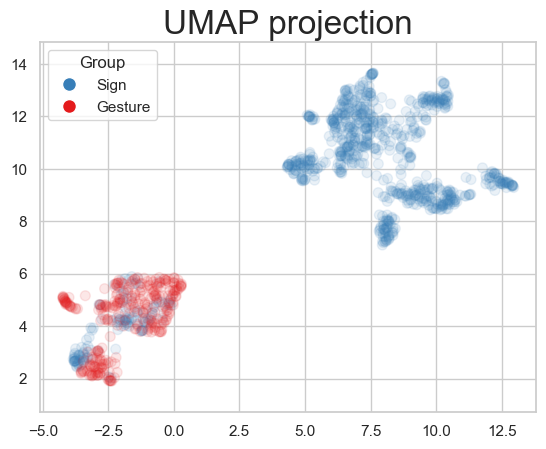

In [384]:
import matplotlib.pyplot as plt
import seaborn as sns

# make color scale for iconicity ratings

sns.color_palette()
# set 5 nicely distinct colors
sns.set_palette("Set1", n_colors=2)
color_palette = sns.color_palette("Set1", n_colors=5)
feat_df['group_macro'] = feat_df['group_macro'].astype('category')

# for each value of handedness, assign a color
group_codes = feat_df['group_macro'].cat.codes


plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[sns.color_palette()[x] for x in group_codes],
    s=50, alpha=0.1)

#add legend to the handedness code
group_codes = group_codes.unique()
group_labels = feat_df['group_macro'].unique()
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label=label, markerfacecolor=sns.color_palette()[code], markersize=10) for code, label in zip(group_codes, group_labels)], title='Group')

#add label to each point according to what concept they represent
# for i, txt in enumerate(feat_df['concept']):
#     plt.annotate(txt, (embedding[i, 0], embedding[i, 1]), fontsize=5)

plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection', fontsize=24);

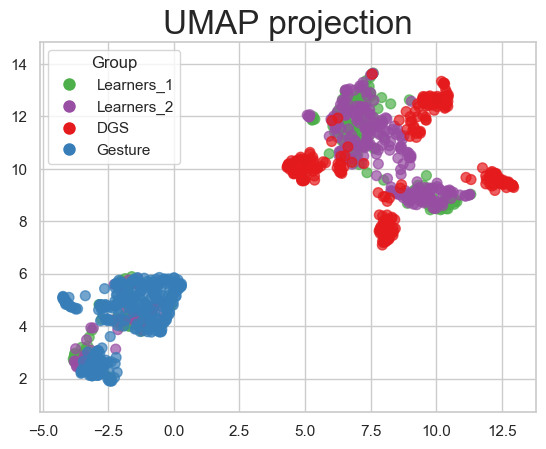

In [385]:
import matplotlib.pyplot as plt
import seaborn as sns

# make color scale for iconicity ratings

sns.color_palette()
# set 5 nicely distinct colors
sns.set_palette("Set1", n_colors=5)
color_palette = sns.color_palette("Set1", n_colors=5)
feat_df['groupID'] = feat_df['groupID'].astype('category')

# for each value of handedness, assign a color
group_codes = feat_df['groupID'].cat.codes


plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[sns.color_palette()[x] for x in group_codes],
    s=50, alpha=0.7)

#add legend to the handedness code
group_codes = group_codes.unique()
group_labels = feat_df['groupID'].unique()
plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', label=label, markerfacecolor=sns.color_palette()[code], markersize=10) for code, label in zip(group_codes, group_labels)], title='Group')

#add label to each point according to what concept they represent
# for i, txt in enumerate(feat_df['concept']):
#     plt.annotate(txt, (embedding[i, 0], embedding[i, 1]), fontsize=5)

plt.gca().set_aspect('equal', 'datalim')
plt.title('UMAP projection', fontsize=24);

In [363]:
# how many times is each groupID represented in feat_df
group_counts = feat_df['group'].value_counts()
group_counts

group
ViCom      46
GP02       21
GP03       21
GP04       21
GP11       21
           ..
LP28_01     9
LP18_02     8
LP08_01     6
IP08_02     4
LP38_01     2
Name: count, Length: 65, dtype: int64

In [386]:
import plotly.express as px
import pandas as pd

# First, make a DataFrame that includes the embedding coordinates
plot_df = pd.DataFrame({
    'x': embedding[:, 0],
    'y': embedding[:, 1],
    'group': feat_df['group'],
    'groupID': feat_df['groupID'],
    'concept': feat_df['concept']
})

# Use Plotly Express for a scatter plot with hover
fig = px.scatter(
    plot_df,
    x='x',
    y='y',
    color='groupID',       # Color by groupID
    symbol='group',        # Optional: differentiate by shape if not too many categories
    hover_name='concept',  # Show the concept name when hovering
    hover_data=['group', 'groupID'],  # Show additional info on hover
    title='UMAP projection (interactive)',
    opacity=0.6
)

# Optional: fix aspect ratio like in matplotlib
fig.update_layout(
    autosize=False,
    width=900,
    height=800,
    title_font_size=24,
    yaxis=dict(scaleanchor="x", scaleratio=1)
)

fig.show()


## Prettier UMAP

In [ ]:
feat_df

,fileID,concept,handedness,group,X_LEFT_ELBOW_Gmean,X_LEFT_ELBOW_Gstd,X_LEFT_ELBOW_peak_mean,X_LEFT_ELBOW_peak_std,X_LEFT_ELBOW_peak_n,X_LEFT_ELBOW_ipi_avg,...,right_wrist_flex_Gstd,right_wrist_flex_peak_mean,right_wrist_flex_peak_std,right_wrist_flex_peak_n,right_wrist_flex_ipi_avg,right_wrist_flex_sampen,right_wrist_flex_integral,right_wrist_flex_ts_range,groupID,group_macro
0,LP28_01_UNTERTITEL_body_world,UNTERTITEL,0,LP28_01,0.190234,0.004741,0.194494,0.004485,4,944.444444,...,7.702750,137.265913,1.449966,2,533.333333,0.108733,15066.475059,20.681580,Learners_1,Sign
1,LP28_01_UMZIEHEN_body_world,UMZIEHEN,0,LP28_01,0.170790,0.012654,0.188197,0.018533,3,983.333333,...,9.773547,150.936057,0.000000,1,0.000000,0.046305,14424.065111,36.603738,Learners_1,Sign
2,LP28_01_DUSCHEN_body_world,DUSCHEN,0,LP28_01,0.194833,0.006442,0.203963,0.008345,2,466.666667,...,18.459391,159.093517,1.772076,2,1233.333333,0.100786,16444.951873,46.624089,Learners_1,Sign
3,LP28_01_HEBEN_body_world,HEBEN,0,LP28_01,0.207692,0.017607,0.232060,0.005607,3,516.666667,...,6.850906,137.015782,0.000000,1,0.000000,0.113185,14579.469951,21.431254,Learners_1,Sign
4,LP29_01_KLAVIER_body_world,KLAVIER,0,LP29_01,0.247117,0.022617,0.282490,0.002555,3,633.333333,...,3.323511,127.132669,3.765187,3,1316.666667,0.279645,14679.373966,13.548260,Learners_1,Sign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
699,IP10_02_SCHMETTERLING_body_world,SCHMETTERLING,0,test_IP,0.127447,0.037167,0.170643,0.032419,2,2300.000000,...,11.053184,146.823564,0.000000,1,0.000000,0.067475,25700.637914,29.190603,test,Sign
700,IP10_02_UNTERTITEL_body_world,UNTERTITEL,0,test_IP,0.225492,0.026540,0.257653,0.014953,5,420.000000,...,3.289713,121.995865,0.684139,6,728.000000,0.167054,23701.060078,11.520626,test,Sign
701,IP06_02_PARTY_body_world,PARTY,2s,test_IP,0.233107,0.035420,0.277570,0.001349,2,1280.000000,...,4.500199,133.103618,0.897504,2,1040.000000,0.270529,12610.423929,12.804236,test,Sign
702,IP10_02_SAXOPHON_body_world,SAXOPHON,0,test_IP,0.188119,0.019777,0.214854,0.011221,5,715.000000,...,10.121461,149.861201,2.025575,5,710.000000,0.100434,28650.185767,39.529634,test,Sign


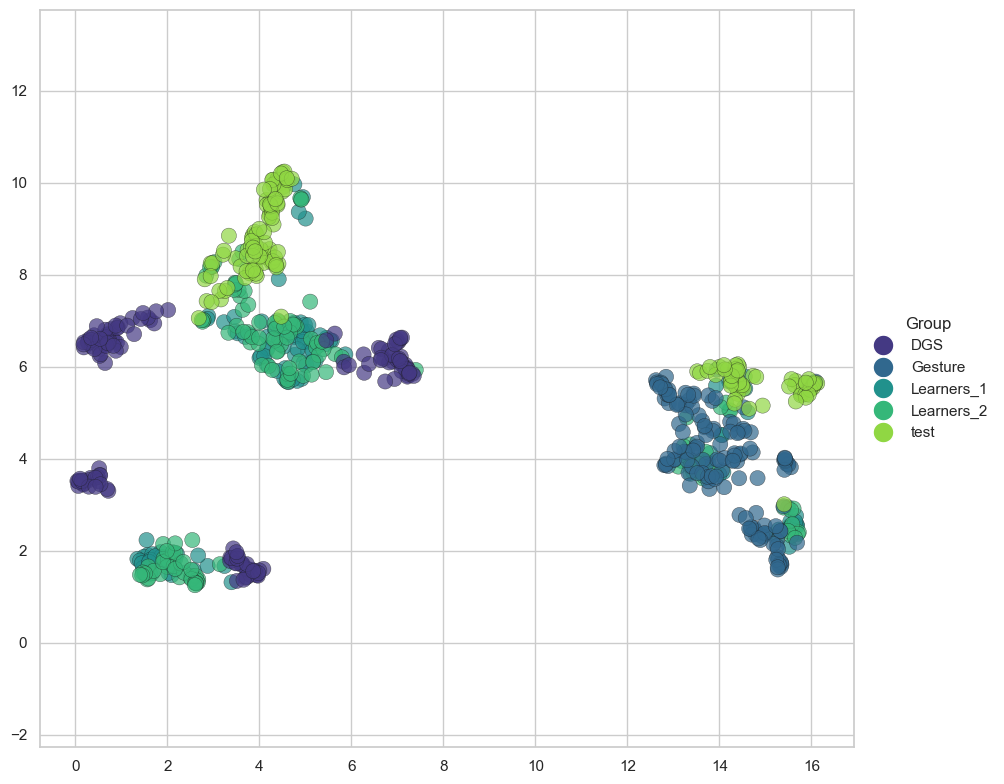

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up figure style and palette
sns.set(style="whitegrid")
#color_palette = sns.color_palette("coolwarm", as_cmap=True)

# pick colorblind-friendly palette
color_palette = sns.color_palette("viridis", as_cmap=True)

# Define handedness groups as categorical
feat_df['groupID'] = feat_df['groupID'].astype('category')
group_codes = feat_df['groupID'].cat.codes

plt.figure(figsize=(12, 8))

# Create scatter plot with enhanced styling
sc = plt.scatter(
    embedding[:, 0],
    embedding[:, 1],
    c=[sns.color_palette("viridis", len(group_codes.unique()))[x] for x in group_codes],
    s=120, alpha=0.7, edgecolor='k', linewidth=0.3
)

# Add legend for group labels, placed outside of the plot
group_labels = feat_df['groupID'].cat.categories
plt.legend(
    handles=[plt.Line2D([0], [0], marker='o', color='w', label=label, 
                        markerfacecolor=sns.color_palette("viridis", len(group_labels))[code],
                        markersize=15) for code, label in enumerate(group_labels)],
    title='Group', loc='center left', bbox_to_anchor=(1, 0.5), frameon=False
)

# Optional: Label each point by concept (uncomment if needed)
# for i, txt in enumerate(feat_df['concept']):
#     plt.annotate(txt, (embedding[i, 0], embedding[i, 1]), fontsize=8, ha='right')

# Set plot title and axis style
#plt.title('UMAP Projection of Features', fontsize=20, weight='bold')
#plt.xlabel('UMAP 1', fontsize=14)
#plt.ylabel('UMAP 2', fontsize=14)
plt.gca().set_aspect('equal', 'datalim')
# xlim, ylim
#plt.ylim(1, 10)

# Display plot
plt.tight_layout(rect=[0, 0, 0.85, 1])  # Adjust layout for legend
plt.show()


In [ ]:
# save this plot
plt.savefig(curfolder + '/plots/umap_sample_plot.svg', dpi=300)

<Figure size 640x480 with 0 Axes>

# Some plots for BH

In [ ]:
# load in sample
sampledf = pd.read_csv(datasetsfolder + '/sampled_eq_f150.csv')

In [ ]:
# Convert 'bbmv_arms' from m³ to cm³
sampledf['bbmv_arms'] = sampledf['bbmv_arms'] *1000

# log intermittency_rwrist
sampledf['intermittency_rwrist'] = np.log(sampledf['intermittency_rwrist']) 

# convert RIGHT_WRIST_acceleration_mean_peak to m/s² from m/ms² (with sampling rate of 120 Hz)
sampledf['RIGHT_WRIST_acceleration_peak_mean'] = sampledf['RIGHT_WRIST_acceleration_peak_mean'] * 100*30

In [ ]:
# convert RIGHT_WRIST_acceleration_mean_peak to m/s² from m/ms² (with sampling rate of 120 Hz)
sampledf['RIGHT_WRIST_speed_peak_mean'] = sampledf['RIGHT_WRIST_speed_peak_mean'] * 100*30

In [ ]:
sampledf['RIGHT_WRIST_speed_integral'] = sampledf['RIGHT_WRIST_speed_integral'] * 100

In [ ]:
sampledf['groupID']

0      Learners_1
1      Learners_1
2      Learners_1
3      Learners_1
4      Learners_1
          ...    
699          test
700          test
701          test
702          test
703          test
Name: groupID, Length: 704, dtype: category
Categories (5, object): ['DGS', 'Gesture', 'Learners_1', 'Learners_2', 'test']

In [ ]:
# DONE // bbmv_arms                              
# DONE // intermittency_rwrist
# DONE // RIGHT_WRIST_acceleration_ipi_avg
# DONE (but might need to adjust conversion // acceleration_mean_peak
# DONE peak_n
# DONE (but convert) RIGHT_WRIST_speed_peak_mean
# DONE also integral

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
import seaborn as sns

vartoplot = 'peak_n'
label = 'distance (in cm)'

# Remove outliers using Tukey's rule
# Q1 = sampledf[vartoplot].quantile(0.25)
# Q3 = sampledf[vartoplot].quantile(0.75)
# IQR = Q3 - Q1
# sampledf = sampledf[(sampledf[vartoplot] > (Q1 - 1.5 * IQR)) & (sampledf[vartoplot] < (Q3 + 1.5 * IQR))]

# Order sampledf by group
sampledf['groupID'] = sampledf['groupID'].astype('category')
#sampledf['groupID'] = sampledf['groupID'].cat.reorder_categories(['Gesture', 'Learners_1', 'Learners_2', 'DGS'], ordered=True)

# Set up style
sns.set(style="whitegrid", context="notebook")
plt.figure(figsize=(12, 7))

# Create boxplot with gradient and custom palette
box_palette = sns.color_palette("Spectral", len(sampledf['groupID'].unique()))
sns.boxplot(
    data=sampledf,
    x='groupID',
    y=vartoplot,
    palette=box_palette,
    width=0.5,
    linewidth=1.5,
    fliersize=0  # Hide default outliers
)

# Enhanced strip plot with varied color points for each group
sns.stripplot(
    data=sampledf,
    x='groupID',
    y=vartoplot,
    palette=box_palette,
    edgecolor='gray', 
    linewidth=0.6,
    alpha=0.7,        # Increase transparency for better layering
    size=6,           # Slightly larger points
    jitter=0.25       # More spread for individual points
)

# Title and labels with larger fonts and contemporary style
#plt.title("Volume Distribution Across Groups", fontsize=20, weight='bold', color="#333333")
#plt.xlabel("Group ID", fontsize=16, labelpad=10)
plt.ylabel(label, fontsize="25", labelpad=10)

# Customize axes and layout
plt.xticks(fontsize=25)
plt.yticks(fontsize=25)
plt.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.3)
plt.tight_layout()

# Display the plot
plt.show()


# save this plot
# name
plotname = f'{vartoplot}_boxplot.png'
plt.savefig(curfolder + '/plots/' + plotname, dpi=300)






ValueError: Could not interpret value `peak_n` for `y`. An entry with this name does not appear in `data`.

<Figure size 1200x700 with 0 Axes>

TODO
- run it on all